This script is used to check the SSP and RCP CO2 and GSL.


In [5]:
import numpy as np
import pandas as pd
from pathlib import Path

SCENARIOS = ["natural", "SSP126", "SSP245", "SSP370", "SSP585", "10000PGC"]

COLOURS = {
    "natural":  "black",
    "SSP126":   "blue",   # [0  0.5  0  ]
    "SSP245":   "green",   # [0  0.45 0.7]
    "SSP370":   "orange",   # [1  0.5  0  ]
    "SSP585":   "red",   # [0.8 0   0  ]
    "10000PGC": "darkmagenta",   # [0.5 0   0  ]
}
LIGHT_COLOURS = {
    "natural":  "lightgrey",
    "SSP126":   "#CCE5CC",
    "SSP245":   "#CCE0F2",
    "SSP370":   "#FFE5CC",
    "SSP585":   "#FFE5E5",
    "10000PGC": "#FFCCCC",
}

path = Path("/Users/bo20541/Library/CloudStorage/OneDrive-UniversityofBristol/NWS-PDRA/climate_emulation_workflow/2_GSL_model/results/emul_inputs_updatedCO2/")

co2 = {}
gsl = {}
for scen in SCENARIOS:
    co2_list, gsl_list = [], []
    for i in range(1, 91):
        F = pd.read_csv(path / f"emul_inputs_{scen}.{i}.updated.res", header=0, sep=r'\s+')
        co2_list.append(F['co2'].values)
        gsl_list.append(F['ice'].values)
    co2[scen] = np.array(co2_list)
    gsl[scen] = np.array(gsl_list)

print({s: co2[s].shape for s in SCENARIOS})

{'natural': (90, 1001), 'SSP126': (90, 1001), 'SSP245': (90, 1001), 'SSP370': (90, 1001), 'SSP585': (90, 1001), '10000PGC': (90, 1001)}


In [6]:
# Quick sanity check — first 10 values of member 67
m = 66
for scen in SCENARIOS:
    print(f"{scen:10s}  CO2: {co2[scen][m, :5]}  GSL: {gsl[scen][m, :5]}")

natural     CO2: [266.75 264.92 263.23 261.71 260.39]  GSL: [ 0.    -3.356 -5.047 -6.563 -7.819]
SSP126      CO2: [410.27 302.67 299.39 284.23 280.7 ]  GSL: [0.    5.008 3.732 2.735 1.961]
SSP245      CO2: [410.27 325.89 319.25 314.59 311.19]  GSL: [ 0.    15.46  12.4   10.53   9.028]
SSP370      CO2: [410.3  425.7  398.43 383.87 372.77]  GSL: [ 0. 24. 24. 24. 24.]
SSP585      CO2: [410.34 894.23 731.32 670.9  629.26]  GSL: [ 0. 24. 24. 24. 24.]
10000PGC    CO2: [ 410.37 1380.8  1090.8   980.38  909.18]  GSL: [ 0. 24. 24. 24. 24.]


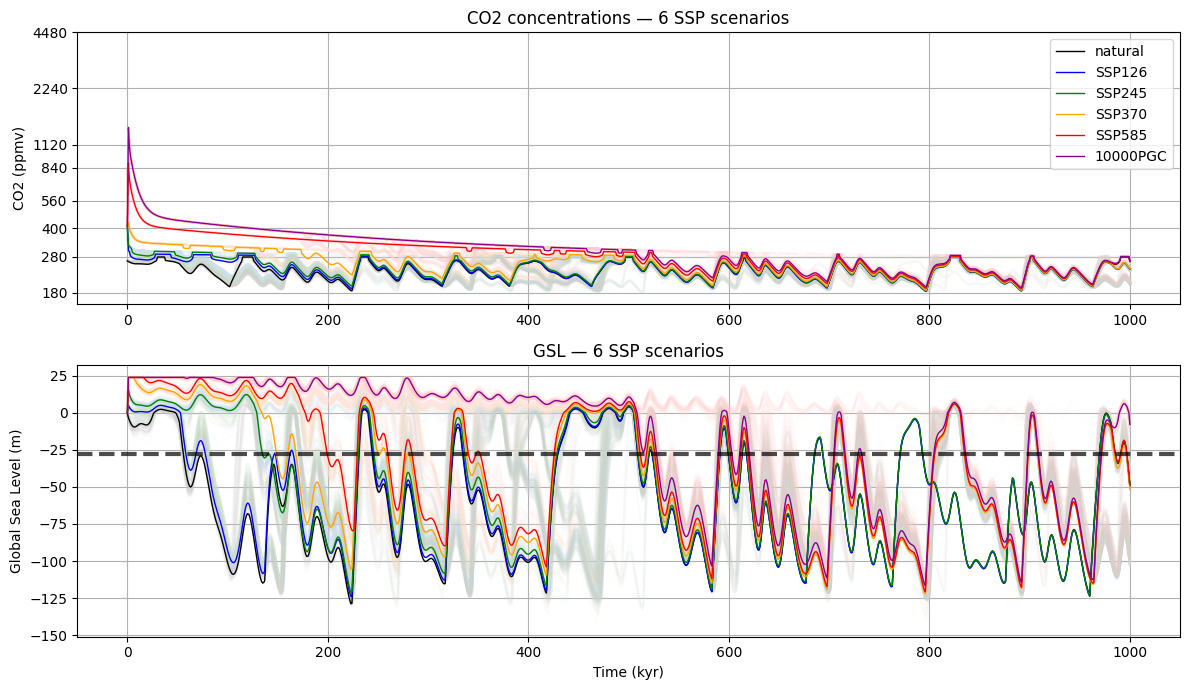

In [7]:
import matplotlib.pyplot as plt

# Log-transform CO2
log_co2 = {scen: np.log(co2[scen]) for scen in SCENARIOS}

time = np.arange(co2["natural"].shape[1])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

# CO2
for i in range(90):
    for scen in SCENARIOS:
        ax1.plot(time, log_co2[scen][i], color=LIGHT_COLOURS[scen], alpha=0.05)
for scen in SCENARIOS:
    ax1.plot(time, log_co2[scen][66], color=COLOURS[scen], label=scen, linewidth=1)

ppm_ticks = np.array([180, 280, 400, 560, 840, 1120, 2240, 4480], dtype=float)
ax1.set_yticks(np.log(ppm_ticks))
ax1.set_yticklabels([str(int(v)) for v in ppm_ticks])
ax1.set_ylabel('CO2 (ppmv)')
ax1.set_title('CO2 concentrations — 6 SSP scenarios')
ax1.legend()
ax1.grid()

# GSL
for i in range(90):
    for scen in SCENARIOS:
        ax2.plot(time, gsl[scen][i], color=LIGHT_COLOURS[scen], alpha=0.05)
for scen in SCENARIOS:
    ax2.plot(time, gsl[scen][66], color=COLOURS[scen], label=scen, linewidth=1)
ax2.axhline(-28, color='black', linewidth=3, linestyle='dashed', alpha=0.7)
ax2.set_xlabel('Time (kyr)')
ax2.set_ylabel('Global Sea Level (m)')
ax2.set_title('GSL — 6 SSP scenarios')
ax2.grid()

plt.tight_layout()
plt.show()

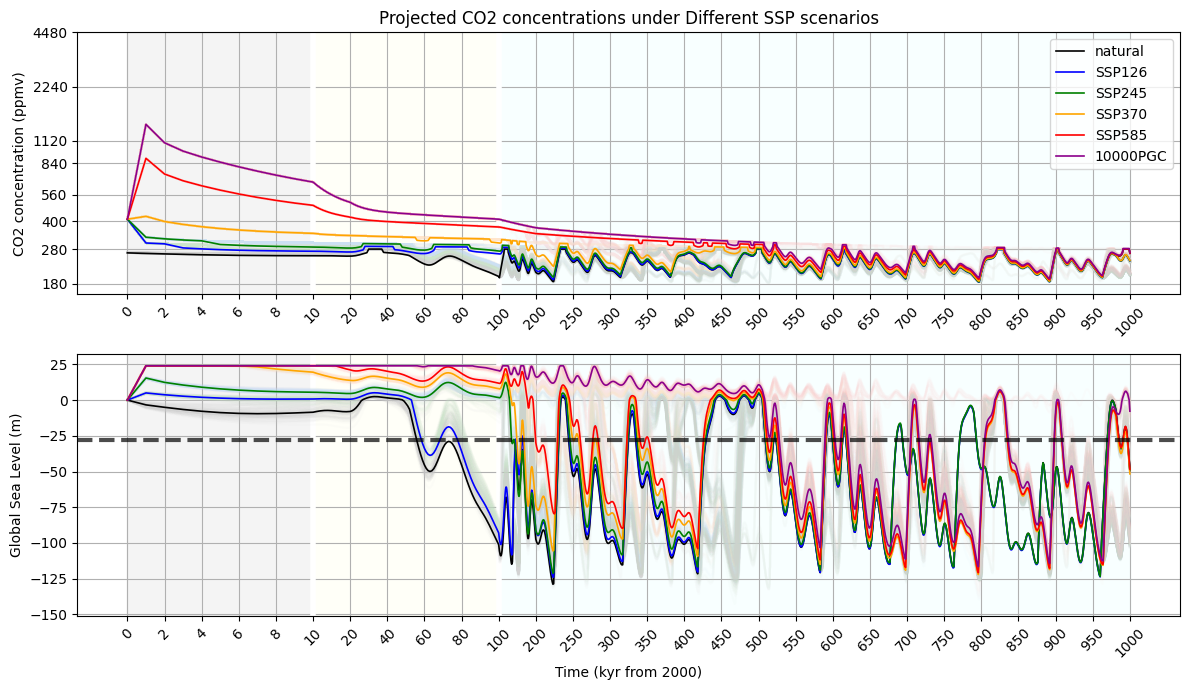

In [9]:
import matplotlib.pyplot as plt

# ---- Irregular X axis: finer near-term, coarser long-term ----
anchor_years = np.concatenate([
    np.arange(0, 11, 2),
    np.arange(20, 101, 20),
    np.arange(200, 1001, 50),
]).astype(float)
anchor_pos  = np.arange(len(anchor_years), dtype=float)
full_years  = np.arange(co2["natural"].shape[1], dtype=float)
x_display   = np.interp(full_years, anchor_years, anchor_pos)
x10         = np.interp(10,  anchor_years, anchor_pos)
x100        = np.interp(100, anchor_years, anchor_pos)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

for ax in (ax1, ax2):
    ax.axvspan(x_display[0], x10,          color='lightgrey',   alpha=0.24, zorder=0)
    ax.axvspan(x10,          x100,          color='lightyellow', alpha=0.20, zorder=0)
    ax.axvspan(x100,         x_display[-1], color='lightcyan',   alpha=0.20, zorder=0)
    ax.axvline(x10,  color='white', linewidth=4)
    ax.axvline(x100, color='white', linewidth=4)
    ax.set_xticks(anchor_pos)
    ax.set_xticklabels(anchor_years.astype(int), rotation=45)
    ax.grid()

# CO2
for i in range(90):
    for scen in SCENARIOS:
        ax1.plot(x_display, log_co2[scen][i], color=LIGHT_COLOURS[scen], alpha=0.05)
for scen in SCENARIOS:
    ax1.plot(x_display, log_co2[scen][66], color=COLOURS[scen], label=scen, linewidth=1.2)

ppm_ticks = np.array([180, 280, 400, 560, 840, 1120, 2240, 4480], dtype=float)
ax1.set_yticks(np.log(ppm_ticks))
ax1.set_yticklabels([str(int(v)) for v in ppm_ticks])
ax1.set_ylabel('CO2 concentration (ppmv)')
ax1.set_title('Projected CO2 concentrations under Different SSP scenarios')
ax1.legend(loc='upper right')

# GSL
for i in range(90):
    for scen in SCENARIOS:
        ax2.plot(x_display, gsl[scen][i], color=LIGHT_COLOURS[scen], alpha=0.05)
for scen in SCENARIOS:
    ax2.plot(x_display, gsl[scen][66], color=COLOURS[scen], label=scen, linewidth=1.2)
ax2.axhline(-28, color='black', linewidth=3, linestyle='dashed', alpha=0.7, label='−28 m threshold')
ax2.set_xlabel('Time (kyr from 2000)')
ax2.set_ylabel('Global Sea Level (m)')

plt.tight_layout()
plt.savefig('Plots/CO2_GSL_SSP.png', dpi=300)
plt.show()